In [1]:
import numpy as np
import pickle
import torch
import time
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import src.learning as lrn
from src.safetymaps import *
from src.reachsteering import HdaGreedy, HdaReachSteering
from src.visualization import *
%load_ext autoreload
%autoreload 2
%matplotlib inline

C:\Users\ktomita3\.conda\envs\pygmo3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def visualize_traj(hda):
    t, X, U = hda.construct_trajectory()
    fig, axs = plot_3sides(t[:-1], X, U=None, uskip=1)
    n_traj = len(hda.X_list)
    for i in range(n_traj):
        t_ = hda.t_list[i]
        X_ = hda.X_list[i]
        U_ = hda.U_list[i]
        fig, axs = plot_3sides(t_[:-1], X_, U=None, uskip=1, fig=fig, axs=axs, linetype='k:')

        axs[0, 0].scatter(X_[0, 0], X_[0, 1], marker='o', color='r')
        axs[1, 0].scatter(X_[0, 0], X_[0, 2], marker='o', color='r')
        axs[1, 1].scatter(X_[0, 1], X_[0, 2], marker='o', color='r')

    # tight layout
    plt.tight_layout()

    return fig, axs

def visualize_profiles(hda, lander):
    t, X, U = hda.construct_trajectory()
    plot_vel(t, X, lander.vmax)
    plot_mass(t, X, lander.mdry, lander.mwet)
    plot_thrust_mag(t[:-1], U, lander.rho2, lander.rho1)
    plot_pointing(t[:-1], U, lander.pa)
    

In [3]:
def visualize_nn_reach(hda, n_skip=1, fontsize=16):
    # make font times new roman
    plt.rcParams["font.family"] = "Times New Roman"

    sfmap_list = hda.sfmap_list[1:]
    reach_mask_list = hda.reachmask_list
    t_list = hda.t_list

    # skip
    sfmap_list = sfmap_list[::n_skip]
    reach_mask_list = reach_mask_list[::n_skip]
    t_list = t_list[::n_skip]
    # print their len
    print(f'Number of maps: {len(sfmap_list)}')
    print(f'Number of reachability masks: {len(reach_mask_list)}')
    print(f'Number of time steps: {len(t_list)}')
    

    n_map = len(sfmap_list) 
    fig, axs = plt.subplots(1, n_map, figsize=(5*n_map, 6), sharey=True, sharex=True)
    for i in range(n_map):

        sfmap = sfmap_list[i]
        reach_mask = reach_mask_list[i]
        t = t_list[i][0]
    

        n = int(np.sqrt(sfmap.shape[0]))

        x = sfmap[:, 0].reshape(n, n)
        y = sfmap[:, 1].reshape(n, n)
        safety = sfmap[:, 2].reshape(n, n)
        reach_mask = reach_mask.reshape(n, n)

        # Safety Map
        safety_img = axs[i].pcolormesh(x, y, safety, shading='auto', cmap='gray', vmin=0, vmax=1)
        #plt.colorbar(safety_img, ax=axs[i], orientation='vertical', label='Safety')

        # Reachability Set - as the overlay with transparency
        reach_mask[reach_mask <= 0.4] = np.nan
        reachability_img = axs[i].pcolormesh(x, y, reach_mask, shading='auto', cmap='jet', alpha=0.5, vmin=0, vmax=1)
        #plt.colorbar(reachability_img, ax=axs[i], orientation='vertical', label='Reachability')

        axs[i].set_title(f't={t:.0f} s', fontsize=fontsize)
        if i == 0:
            axs[i].set_ylabel('y, m', fontsize=fontsize)
        axs[i].set_xlabel('x, m', fontsize=fontsize)
        axs[i].set_aspect('equal')
        # set font size
        axs[i].tick_params(labelsize=fontsize)


    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([1.0, 0.15, 0.01, 0.7])  # [left, bottom, width, height]
    fig.colorbar(safety_img, ax=axs[-1], cax=cbar_ax)
    # colorbar ticks font size
    cbar_ax.tick_params(labelsize=fontsize)
    # colorbar label
    cbar_ax.set_ylabel("Safety", rotation=270, labelpad=20, fontsize=fontsize)
    # tight layout
    plt.tight_layout()
    return fig, axs

In [46]:
with open('../saved/controllable_set/lander.pkl', 'rb') as f:
        lander = pickle.load(f)

hidden_layers = [256, 256, 256]
nn_reach = lrn.NeuralReach(hidden_layers=hidden_layers)
#nn_reach.load_state_dict(torch.load('../saved/controllable_set/reachset_train/20231115-025054/models_20231130-175526/mlp_reach/mlp_reach.pt'))
nn_reach.load_state_dict(torch.load('../saved/controllable_set/reachset_train/20231115-025054/models_20240808-162255/mlp_reach/mlp_reach.pt'))
nn_reach.eval()

#sfmap_model = StaticSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=100)
#sfmap_model = DynamicSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=100, relative_path="..")
#sfmap_model = StaticNoisedSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=100)
#sfmap_model = DesignedSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=100, n_hazards=[50, 50, 400, 2000, 2000], hazard_sizes=[14, 12,  8, 5, 2])
sfmap_model = DynamicSafetyMap2(x_range=(-300, 300), y_range=(-300, 300), npoints=100, relative_path='../')


#x0_init = np.array([0.0, 0.0, 1400.0, 5, -10, -35.0, lander.mwet])
#x0_init = np.array([0.0, 0.0, 1300.0, 0.0, -5, -55.0, lander.mwet])
#x0_init = np.array([-120.0, -80.0, 1200.0, -1.0, -1, -55.0, lander.mwet])
x0_init = np.array([-85.0, -115.0, 1200.0, -1.0, -1.0, -55.0, lander.mwet])
tof = 60.0
T = 5.0
dt = 0.5

In [81]:
hda_greedy = HdaGreedy(lander, sfmap_model, nn_reach, border_sharpness=5.0)
hda_greedy.solve_hda(x0_init, tof, T, dt)

x0: [-8.500e+01 -1.150e+02  1.200e+03 -1.000e+00 -1.000e+00 -5.500e+01
  1.905e+03], tgo: 60.0
Greedy HDA optimized single leg: 1.6068847179412842 sec
x0: [-9.09244841e+01 -1.16906338e+02  9.65949287e+02 -1.34505044e+00
  1.91704493e-01 -3.85266210e+01  1.87497622e+03], tgo: 55.0
Greedy HDA optimized single leg: 1.6154711246490479 sec
x0: [-9.59460773e+01 -1.17478953e+02  8.15690432e+02 -6.77562871e-01
 -4.03335108e-01 -2.14816002e+01  1.84495665e+03], tgo: 50.0
Greedy HDA optimized single leg: 1.3625571727752686 sec
x0: [-9.78450681e+01 -1.20759323e+02  7.52082180e+02 -9.64755925e-02
 -8.90818888e-01 -3.86350187e+00  1.81494897e+03], tgo: 45.0
Greedy HDA optimized single leg: 1.2223048210144043 sec
x0: [-9.75752682e+01 -1.26040580e+02  7.39889238e+02  1.48934647e-01
 -1.15742495e+00 -4.42191995e+00  1.80020150e+03], tgo: 40.0
Greedy HDA optimized single leg: 1.0882084369659424 sec
x0: [-9.64452943e+01 -1.32207767e+02  7.05982144e+02  2.97057261e-01
 -1.30018902e+00 -9.12912045e+00  1.

Number of maps: 6
Number of reachability masks: 6
Number of time steps: 6


C:\Users\ktomita3\AppData\Local\Temp\ipykernel_20076\2361381571.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


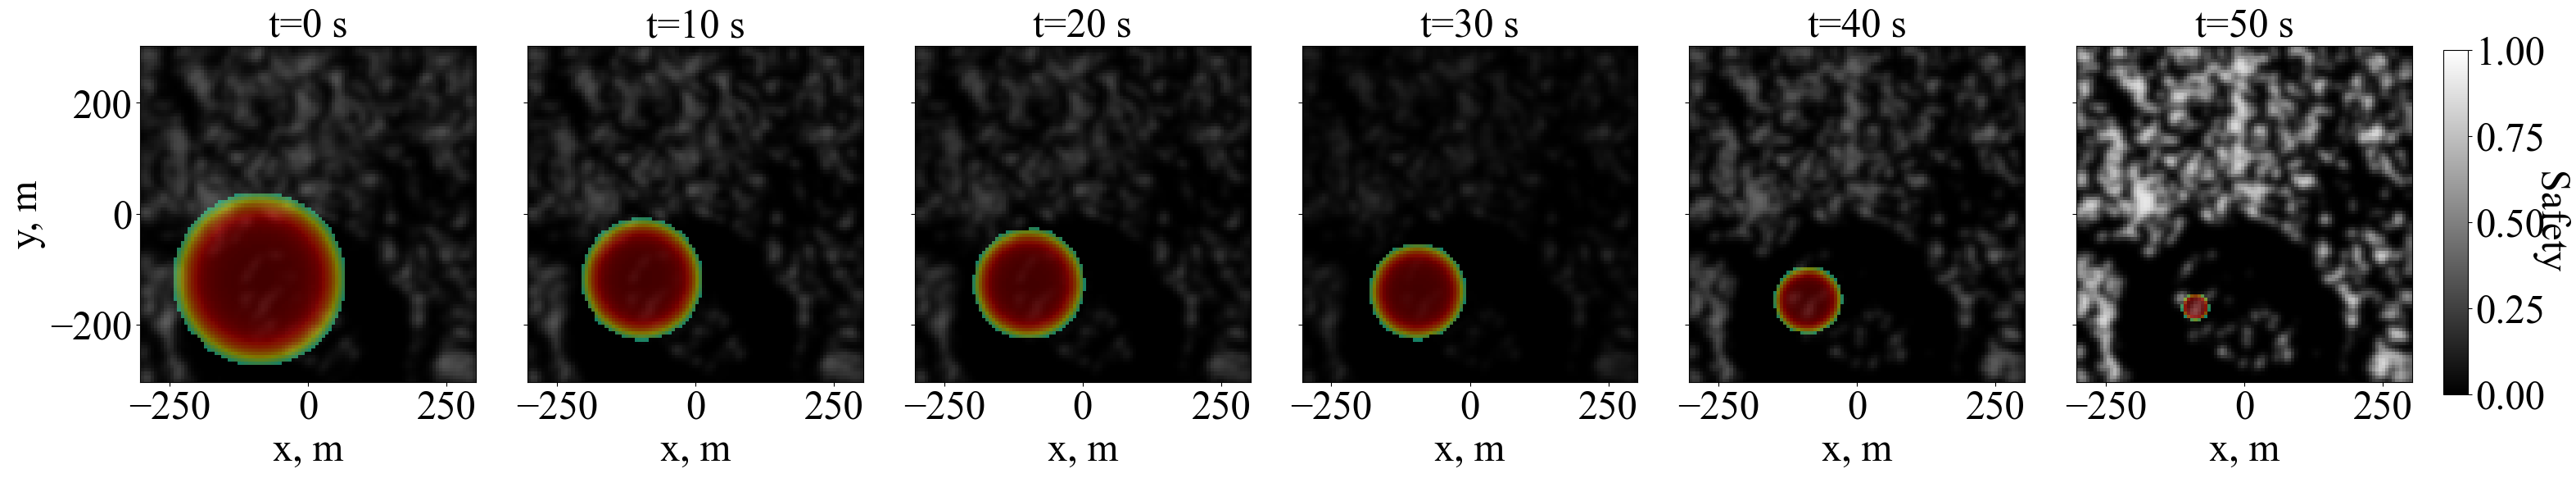

In [95]:
fig, ax = visualize_nn_reach(hda_greedy, n_skip=2, fontsize=35)
#plt.subplots_adjust(wspace=0.02, hspace=0)
plt.savefig('../saved/fig/hda_greedy_reach_transition.png', dpi=300)

In [83]:
hda_rs = HdaReachSteering(lander, sfmap_model, nn_reach, border_sharpness=5.0, alpha=0.7, itr_max=1000, 
                          init_guess_safest=True, n_sol=10, ftol=1e-8)
hda_rs.solve_hda(x0_init, tof, T, dt)

x0: [-8.500e+01 -1.150e+02  1.200e+03 -1.000e+00 -1.000e+00 -5.500e+01
  1.905e+03], tgo: 60.0
Initial guess: 1.626708984375 sec for 1 solutions
Reach-steering HDA optimized single leg: 18.14649772644043 sec
x0: [-9.09244871e+01 -1.16906327e+02  9.65949601e+02 -1.34505224e+00
  1.91710966e-01 -3.85264216e+01  1.87495236e+03], tgo: 55.0
Reach-steering HDA optimized single leg: 8.635012865066528 sec
x0: [-9.81950048e+01 -1.13555479e+02  8.15700003e+02 -1.53755188e+00
  1.10126905e+00 -2.14771664e+01  1.84490473e+03], tgo: 50.0
Reach-steering HDA optimized single leg: 9.571666479110718 sec
x0: [-1.06053046e+02 -1.06358186e+02  7.52167866e+02 -1.58942190e+00
  1.74307694e+00 -3.83702103e+00  1.81485709e+03], tgo: 45.0
Reach-steering HDA optimized single leg: 12.483901023864746 sec
x0: [-1.13992784e+02 -9.69041617e+01  7.39884161e+02 -1.58181094e+00
  1.97834335e+00 -4.44764927e+00  1.80014741e+03], tgo: 40.0
Reach-steering HDA optimized single leg: 45.67547106742859 sec
x0: [-127.55217028 

Number of maps: 6
Number of reachability masks: 6
Number of time steps: 6


C:\Users\ktomita3\AppData\Local\Temp\ipykernel_20076\2361381571.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


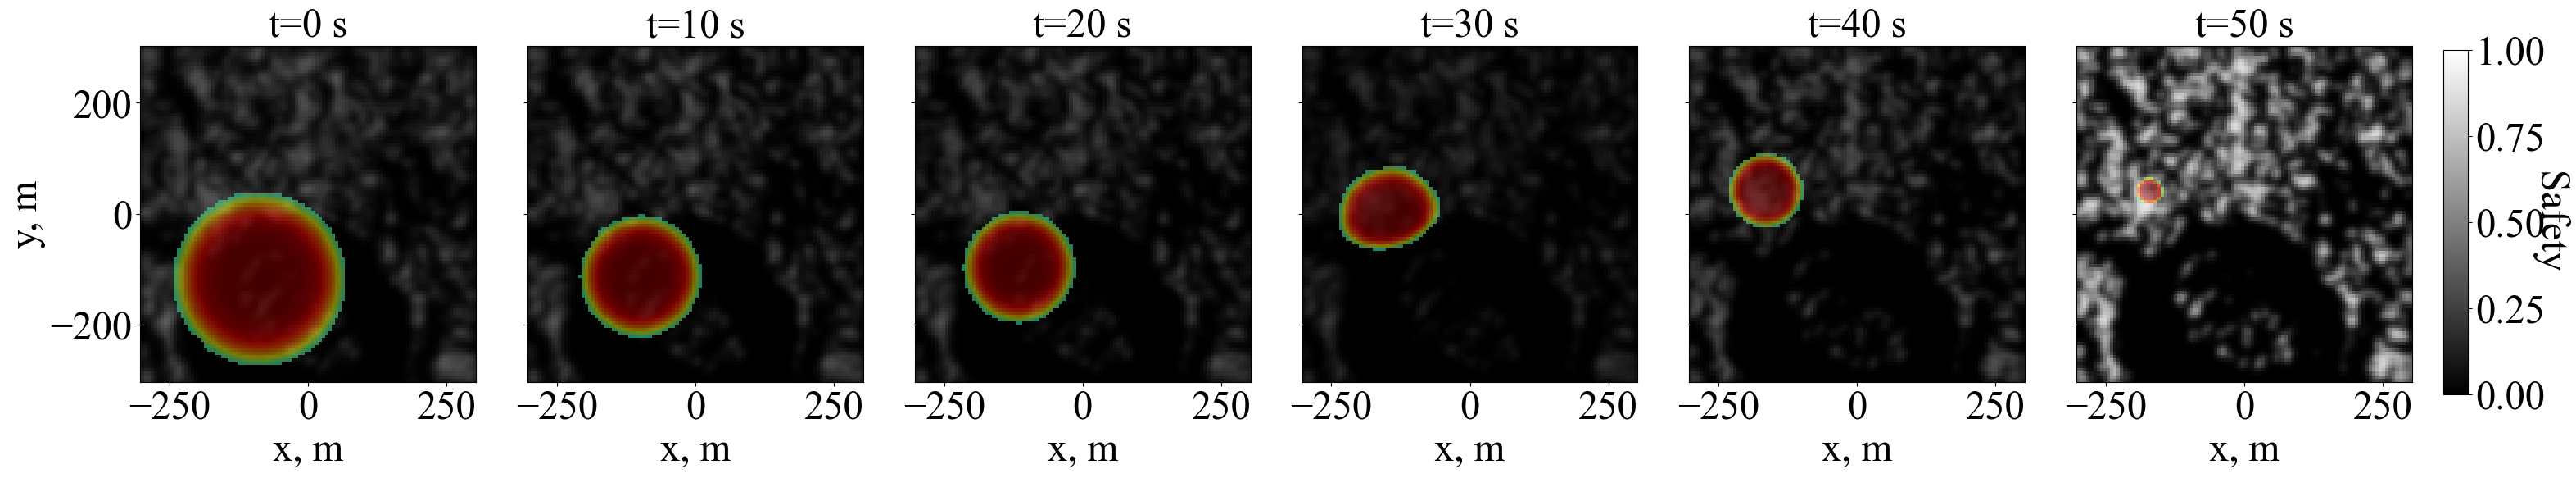

In [94]:
fig, ax = visualize_nn_reach(hda_rs, n_skip=2, fontsize=35)
#plt.subplots_adjust(wspace=0.02, hspace=2.5)
plt.savefig('../saved/fig/hda_rs_reach_transition.png', dpi=300)

Number of maps: 11
Number of reachability masks: 11
Number of time steps: 11


C:\Users\ktomita3\AppData\Local\Temp\ipykernel_20076\2361381571.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Number of maps: 11
Number of reachability masks: 11
Number of time steps: 11


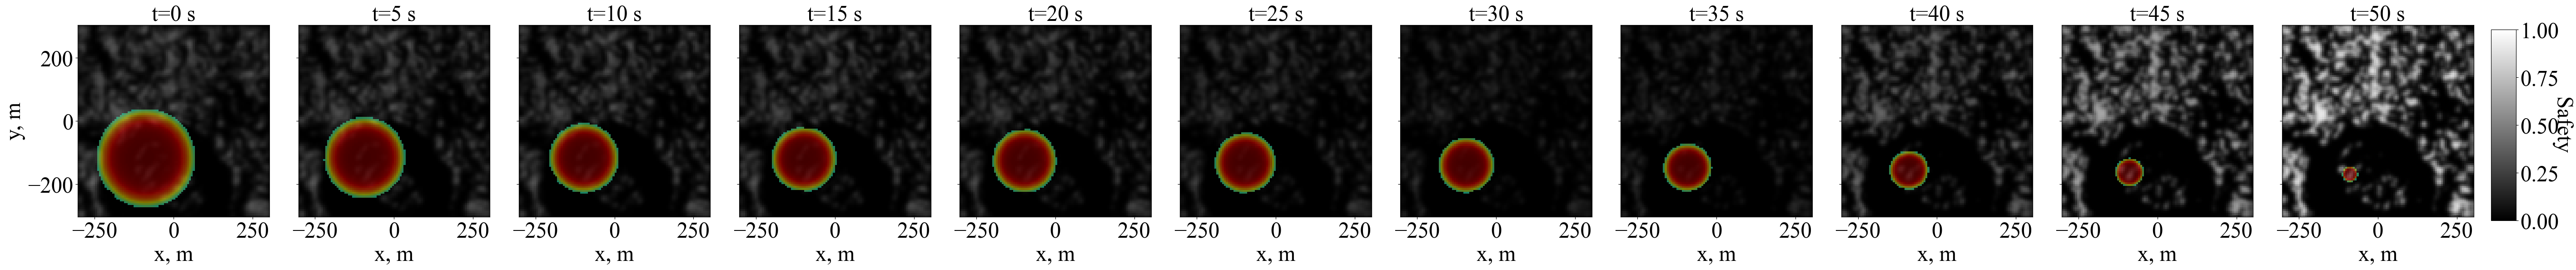

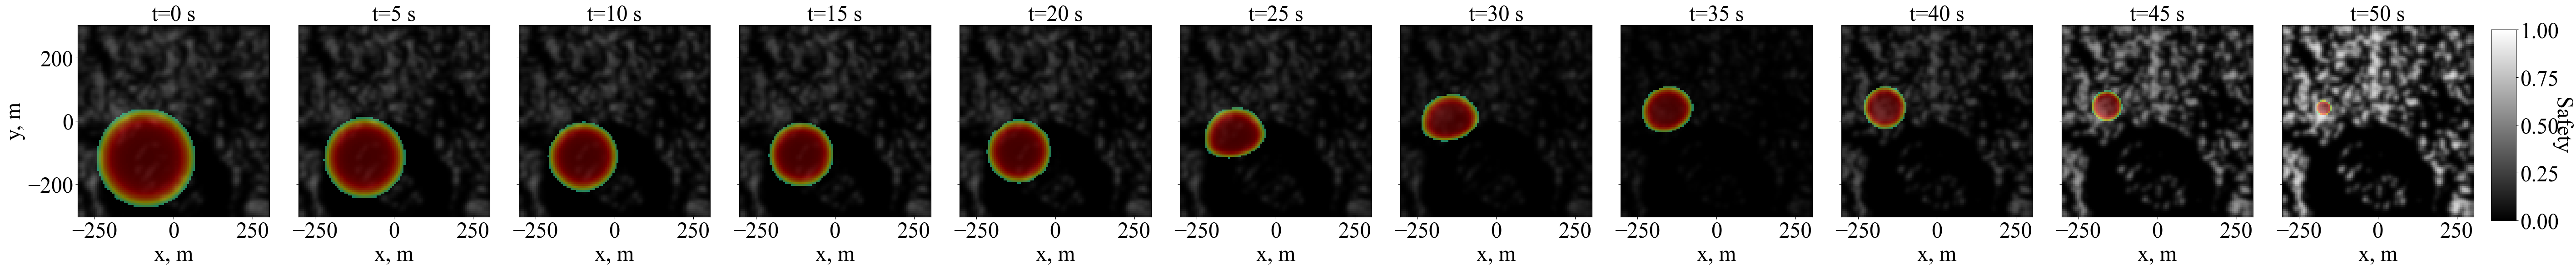

In [85]:
fig, ax = visualize_nn_reach(hda_greedy, n_skip=1, fontsize=35)

fig, ax = visualize_nn_reach(hda_rs, n_skip=1, fontsize=35)

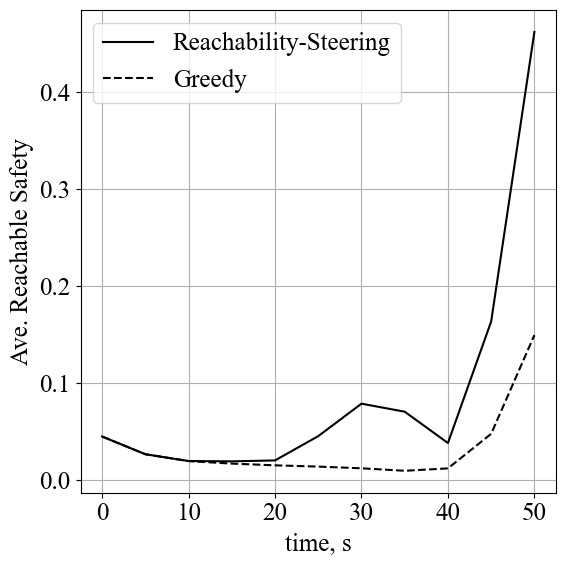

In [86]:
# font size
fontsize = 18
times = np.arange(len(hda_rs.mean_safety_list)) * T
plt.figure(figsize=(6, 6))
plt.plot(times, hda_rs.mean_safety_list, 'k-', label='Reachability-Steering')
plt.plot(times, hda_greedy.mean_safety_list, 'k--', label='Greedy')
plt.xlabel('time, s', fontsize=fontsize)
plt.ylabel('Ave. Reachable Safety', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.tick_params(labelsize=fontsize)
# tight layout
plt.tight_layout()
# grid
plt.grid(True)
# save
#plt.savefig('../saved/fig/mean_reachable_safety.png', dpi=300)

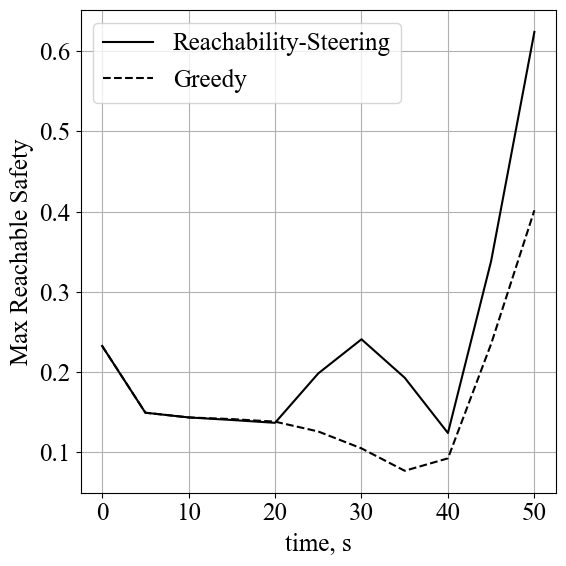

In [87]:
# font size
fontsize = 18
times = np.arange(len(hda_rs.mean_safety_list)) * T
plt.figure(figsize=(6, 6))
plt.plot(times, hda_rs.max_safety_list, 'k-', label='Reachability-Steering')
plt.plot(times, hda_greedy.max_safety_list, 'k--', label='Greedy')
plt.xlabel('time, s', fontsize=fontsize)
plt.ylabel('Max Reachable Safety', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.tick_params(labelsize=fontsize)
# tight layout
plt.tight_layout()
# grid
plt.grid(True)
# save
#plt.savefig('../saved/fig/max_reachable_safety.png', dpi=300)

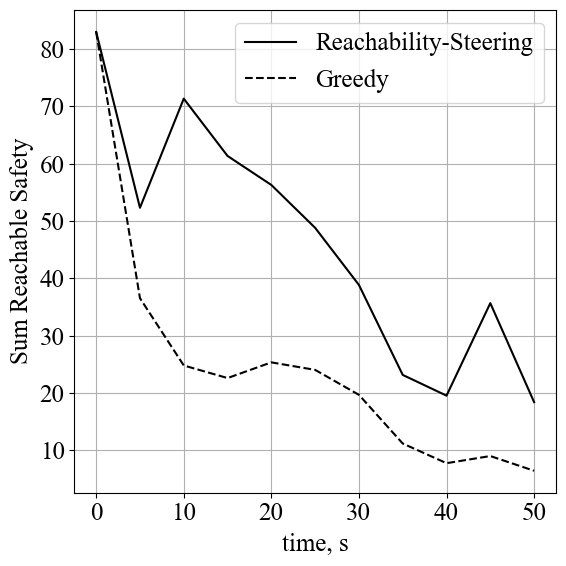

In [50]:
# font size
fontsize = 18
times = np.arange(len(hda_rs.mean_safety_list)) * T
plt.figure(figsize=(6, 6))
plt.plot(times, hda_rs.sum_safety_list, 'k-', label='Reachability-Steering')
plt.plot(times, hda_greedy.sum_safety_list, 'k--', label='Greedy')
plt.xlabel('time, s', fontsize=fontsize)
plt.ylabel('Sum Reachable Safety', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.tick_params(labelsize=fontsize)
# tight layout
plt.tight_layout()
# grid
plt.grid(True)
# save
plt.show()

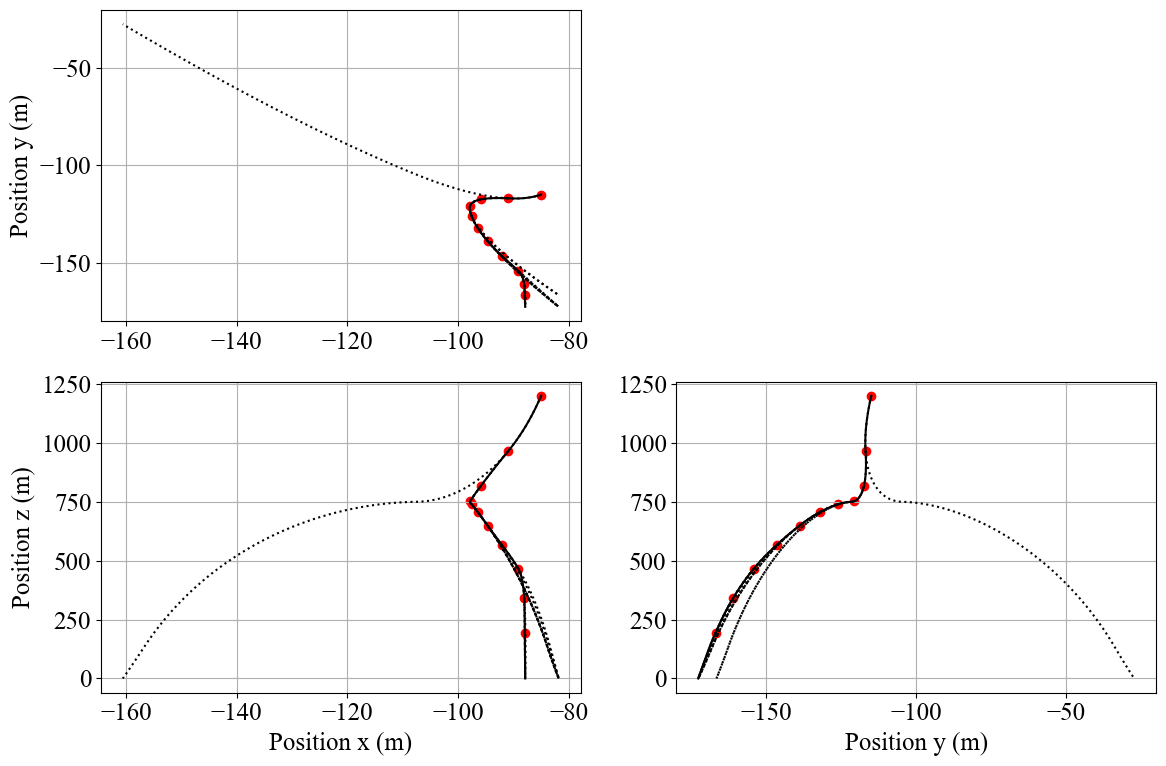

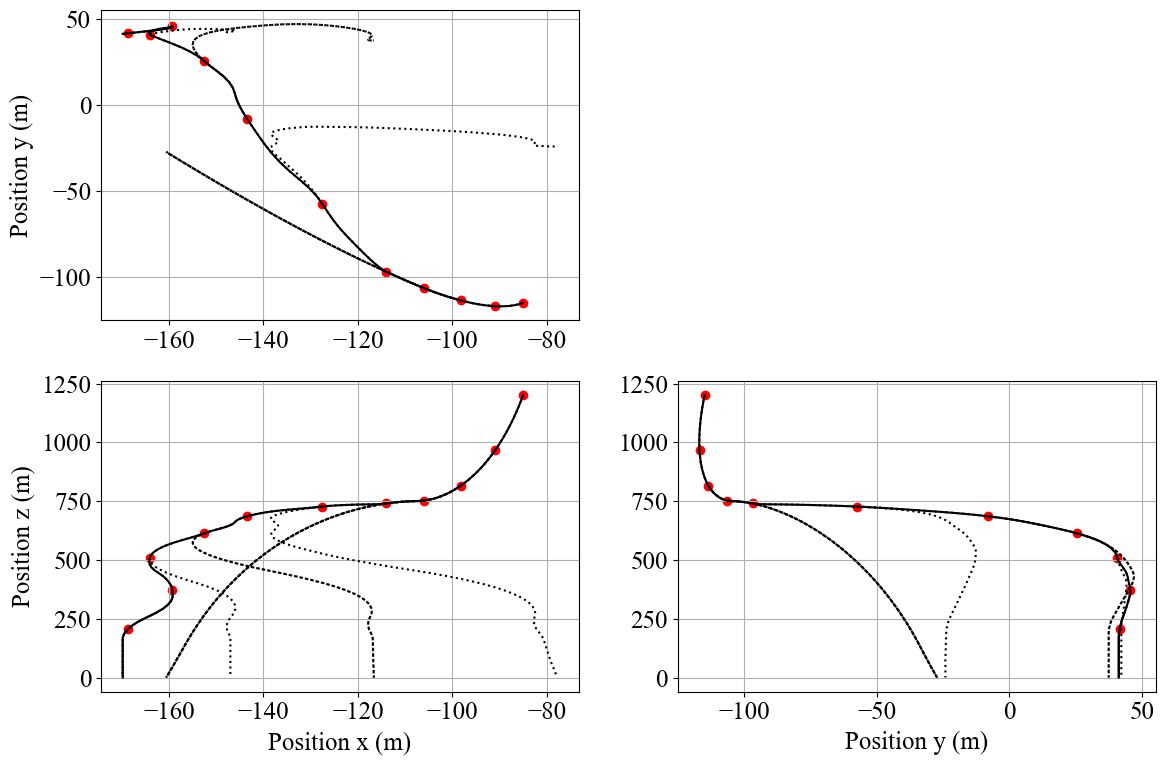

In [89]:
fig, ax = visualize_traj(hda_greedy)
plt.savefig('../saved/fig/traj_greedy.png', dpi=300)

fig, ax = visualize_traj(hda_rs)
plt.savefig('../saved/fig/traj_rs.png', dpi=300)

In [ ]:
hda_greedy = HdaGreedy(lander, sfmap_model, nn_reach, border_sharpness=3.0)
hda_greedy.solve_hda(x0_init, tof, T, dt)

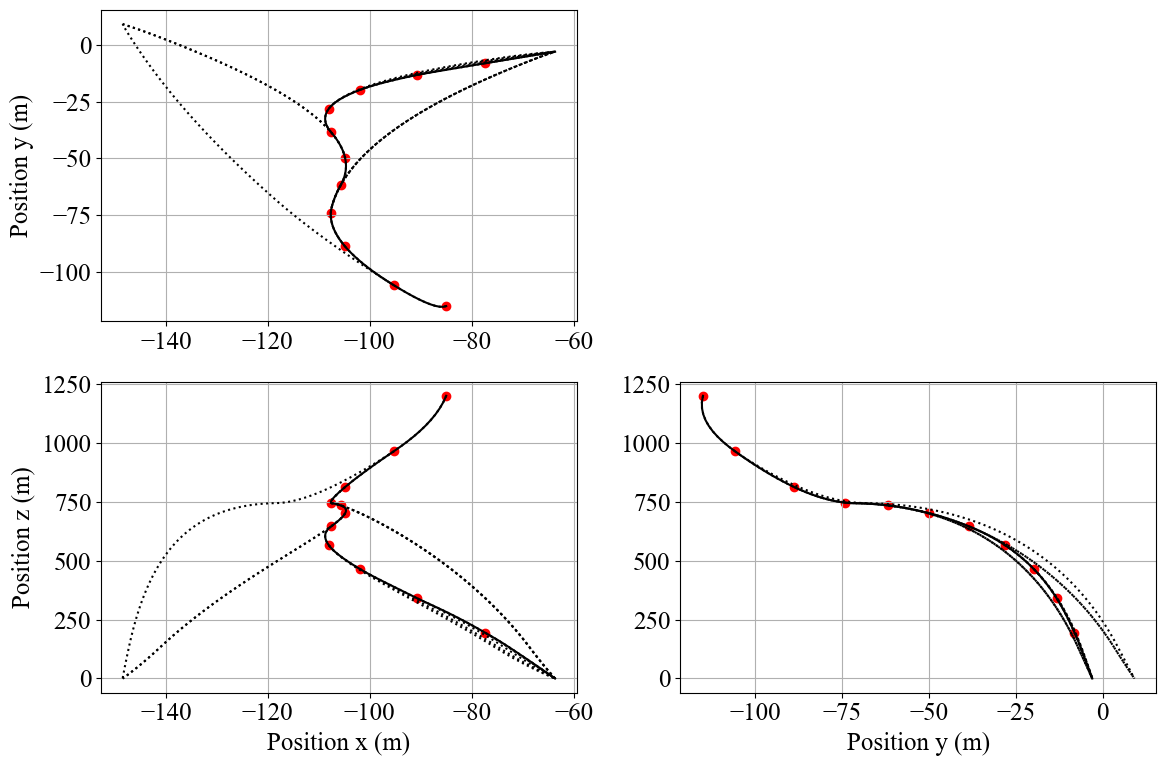

In [52]:
fig, ax = visualize_traj(hda_greedy)
#fig.savefig('../saved/fig/traj_greedy.pdf', bbox_inches='tight')


In [ ]:
visualize_profiles(hda_greedy, lander)

In [ ]:
fig, ax = visualize_nn_reach(hda_greedy, n_skip=2, fontsize=35)
#fig.savefig('../saved/fig/reachset_greeedy.pdf', bbox_inches='tight')
# save png as well
fig.savefig('../saved/fig/reachset_greeedy.png', bbox_inches='tight', dpi=500)


In [ ]:
hda_rs = HdaReachSteering(lander, sfmap_model, nn_reach, border_sharpness=3.0,
                          itr_max=10000, ftol=1e-12, ctol=1e-8)
hda_rs.solve_hda(x0_init, tof, T, dt)

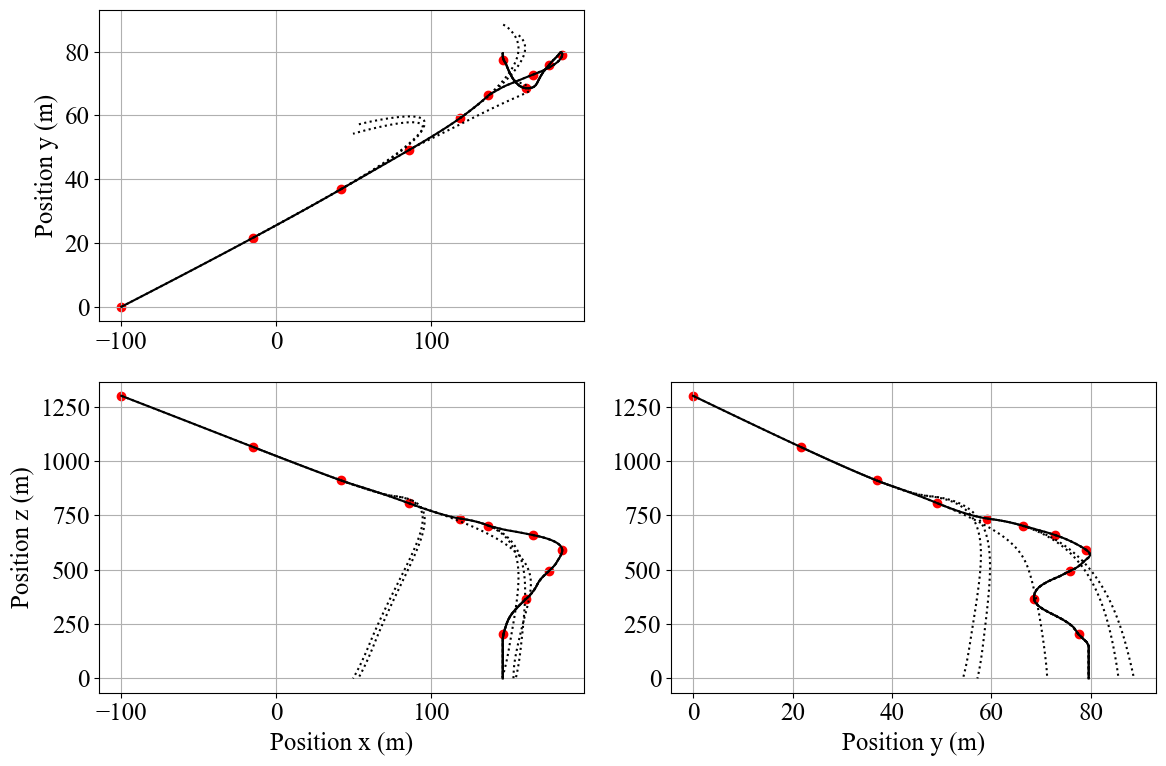

In [17]:
fig, ax = visualize_traj(hda_rs)
fig.savefig('../saved/fig/traj_rs.pdf', bbox_inches='tight')

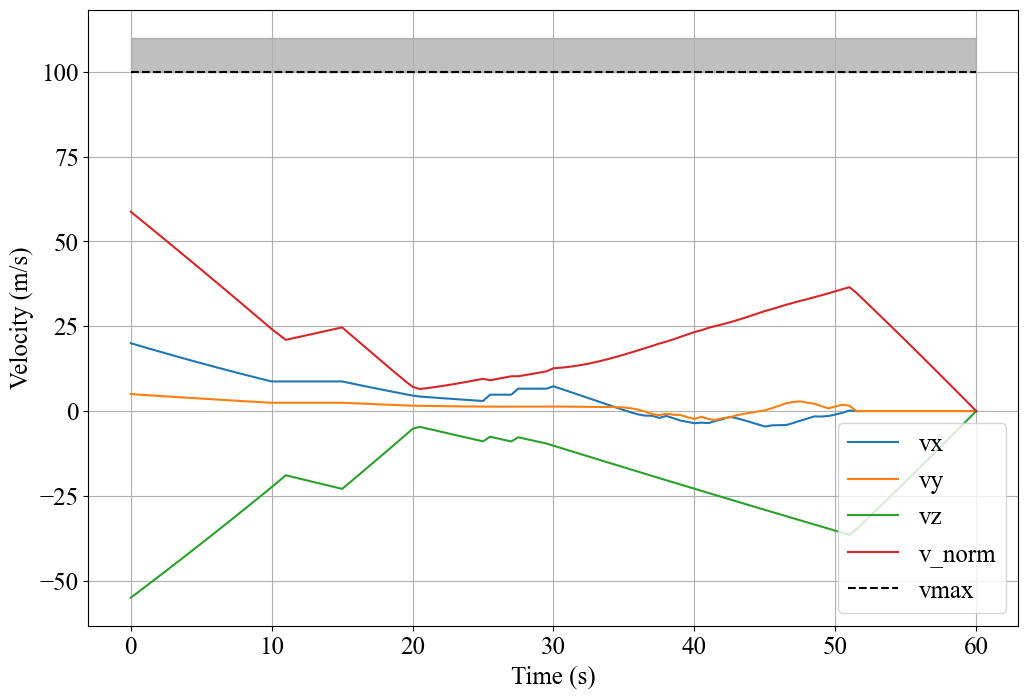

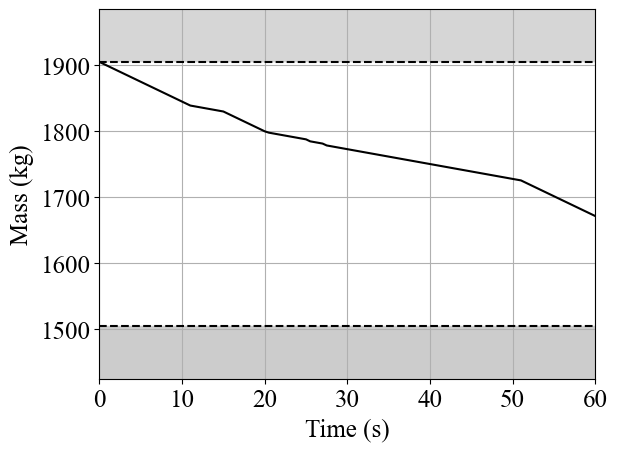

(120,)


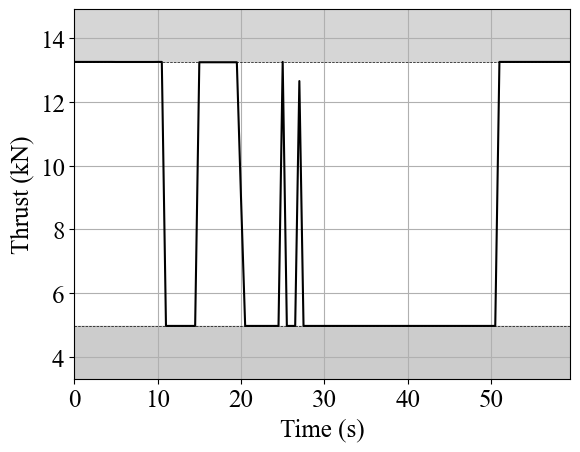

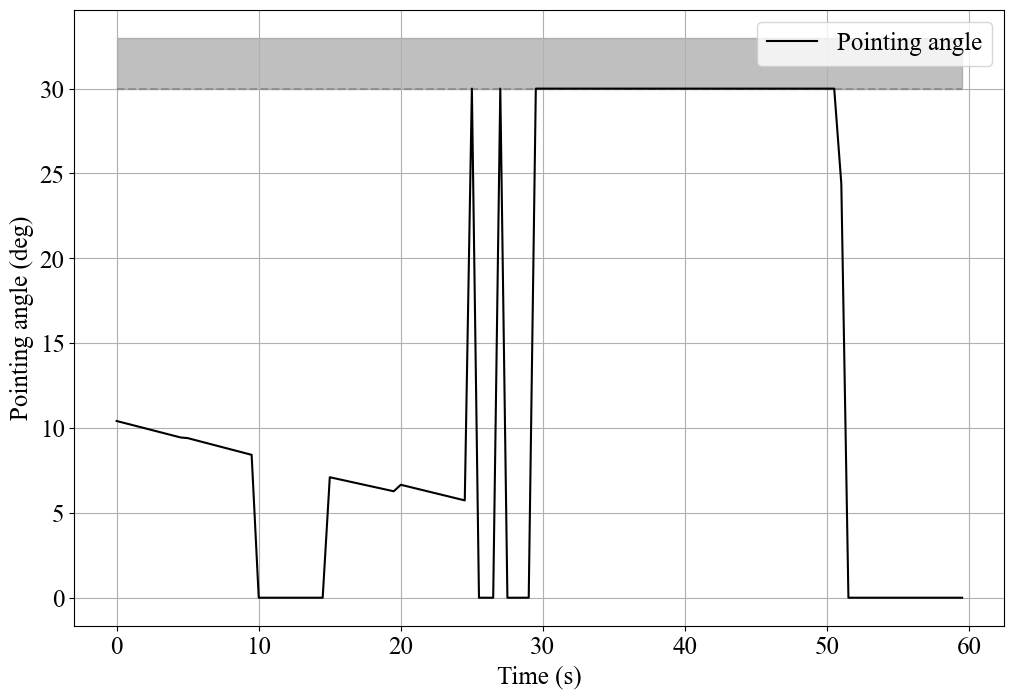

In [16]:
visualize_profiles(hda_rs, lander)

In [ ]:
fig, ax = visualize_nn_reach(hda_rs, n_skip=2, fontsize=35)
fig.savefig('../saved/fig/reachset_rs.pdf', bbox_inches='tight')
# save png as well
fig.savefig('../saved/fig/reachset_rs.png', bbox_inches='tight', dpi=500)

In [ ]:
# font size
fontsize = 18
plt.figure(figsize=(6, 6))
plt.plot(np.arange(11), hda_rs.mean_safety_list, 'k-', label='Reachability-Steering')
plt.plot(np.arange(11), hda_greedy.mean_safety_list, 'k--', label='Greedy')
plt.xlabel('time, s', fontsize=fontsize)
plt.ylabel('Mean Reachable Safety', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.tick_params(labelsize=fontsize)
# tight layout
plt.tight_layout()
# grid
plt.grid(True)
# save
plt.savefig('../saved/fig/mean_reachable_safety.pdf')